In [12]:
print('hi')

hi


In [13]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [14]:
model="openai/gpt-oss-20b"

In [15]:
from langchain_groq import ChatGroq

In [16]:
llm=ChatGroq(model_name=model)

In [17]:
llm.invoke("hi").content

'Hello! How can I help you today?'

In [18]:

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [19]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [20]:
call_model({"messages" : ["Hi!!"]})

{'messages': [AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hi!!". We need to respond with a friendly greeting. There\'s no specific request. Just greet.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 73, 'total_tokens': 117, 'completion_time': 0.062088241, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.00412424, 'prompt_tokens_details': None, 'queue_time': 0.333529793, 'total_time': 0.066212481}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e8de-bd59-7e83-92db-0ee43f4569d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 44, 'total_tokens': 117, 'output_token_details': {'reasoning': 24}})]}

In [21]:
workflow=StateGraph(MessagesState)

In [22]:
workflow.add_node("mybot",call_model)

In [23]:
workflow.add_edge(START,"mybot")

In [24]:
workflow.add_edge("mybot",END)

In [25]:
app=workflow.compile()

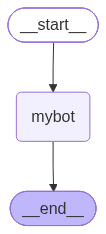

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
input={"messages":["hi hello how are you?"]}

In [28]:
app.invoke(input)

{'messages': [HumanMessage(content='hi hello how are you?', additional_kwargs={}, response_metadata={}, id='a27e684e-5910-40b6-a778-4eb6e46d42a8'),
  AIMessage(content='Hi there! 👋 I’m doing great—thanks for asking. How about you? What’s on your mind today?', additional_kwargs={'reasoning_content': 'The user says "hi hello how are you?" It\'s a friendly greeting. We should respond politely. The user may want a chat. So respond with a friendly greeting and ask how they\'re doing.'}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 77, 'total_tokens': 151, 'completion_time': 0.079605488, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.005390831, 'prompt_tokens_details': None, 'queue_time': 1.103447632, 'total_time': 0.084996319}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3023a70d60', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e8df-0772-7673-9ff2-

In [29]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from mybot Node
_______
{'messages': [AIMessage(content='Hello! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'User says: "hi hello how are you?" We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 77, 'total_tokens': 119, 'completion_time': 0.055383628, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.003708429, 'prompt_tokens_details': None, 'queue_time': 0.351870316, 'total_time': 0.059092057}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_99996fee8e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e8e0-e228-7a90-a4f4-7ed5b40f71b2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 42, 'total_tokens': 119, 'output_token_details': {'reasoning': 15}})]}




In [ ]:
@tool
def search(query:str):
    """this is my custom tool for searching a weather"""
    if "delhi" in query.lower():
        return "the temp is 45 degree and sunny"
    return "the temp is 25 degree and cloudy"

In [ ]:
search.invoke("what is the temperature in hyderabad?")